<a href="https://colab.research.google.com/github/viplove21r/AIML-Models/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is logistic regression?

Logistic regression is a classification algorithm, used to predict categorical outcomes (usually 0 or 1, yes or no, true or false).

Unlike linear regression, which predicts continuous numbers, logistic regression predicts probabilities that the output belongs to a certain class.

Logistic regression finds the best decision boundary (or best separating line/plane).

For 1 feature:

boundary is a point

For 2 features:

boundary is a line

For 3+ features:

boundary is a plane/hyperplane

In [1]:

import numpy as np
import pandas as pd

In [10]:
df=pd.read_csv("/content/placement.csv")

In [11]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. scale the input values to lie in [-1,1]
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [13]:
df=df.iloc[:,1:]

In [14]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [17]:
df.shape

(100, 3)

# EDA

In [18]:
import matplotlib.pyplot as plt

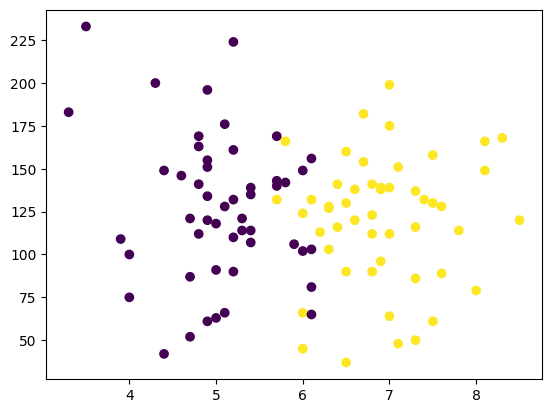

In [20]:
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])

Extract inputs (independent variables) and output(dependent variable) column

In [21]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [22]:
X # 2-d Tensor

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y # 1-d Tensor

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


#Train-Test-Split

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [27]:
X_train

,cgpa,iq
8,6.1,156.0
69,8.5,120.0
7,5.0,63.0
98,6.3,103.0
93,6.8,112.0
...,...,...
90,7.3,86.0
5,7.1,48.0
85,5.8,166.0
62,6.0,102.0


In [28]:
y_train

,placement
8,0
69,1
7,0
98,1
93,1
...,...
90,1
5,1
85,1
62,0


In [29]:
X_test

,cgpa,iq
76,4.9,155.0
29,7.0,112.0
30,7.6,128.0
67,5.0,118.0
18,4.0,100.0
71,6.1,132.0
75,4.8,169.0
12,5.4,139.0
59,4.8,112.0
55,7.8,114.0


#Scale the Values

In [34]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

In [31]:
X_train

array([[ 7.23240007e-02,  7.96350834e-01],
       [ 2.21232183e+00, -7.50360969e-02],
       [-9.08508337e-01, -1.45473207e+00],
       [ 2.50657153e-01, -4.86524370e-01],
       [ 6.96490034e-01, -2.68677637e-01],
       [-9.97674914e-01,  1.76455854e+00],
       [-1.68425755e-02, -1.38211649e+00],
       [-9.97674914e-01, -7.50360969e-02],
       [-1.68425755e-02,  2.17846733e-02],
       [ 1.32065607e+00,  1.67015829e-01],
       [-6.41008609e-01, -2.20267252e-01],
       [ 5.18156882e-01,  3.60657369e-01],
       [-1.17600807e+00, -8.73807451e-01],
       [ 7.85656610e-01, -6.55960718e-01],
       [ 1.23148949e+00,  2.15426214e-01],
       [-8.19341761e-01,  1.18605443e-01],
       [ 7.23240007e-02, -1.01903861e+00],
       [-9.08508337e-01, -7.76986680e-01],
       [-1.95175728e-01,  4.57478139e-01],
       [-1.08684149e+00,  4.33272946e-01],
       [-9.97674914e-01,  6.75324872e-01],
       [-6.41008609e-01, -5.08309043e-02],
       [ 2.03398868e+00,  1.08681314e+00],
       [-1.

In [35]:
# this time we do .transform() because scaler() has already understood the data.
# if we again do fit_transform() it learns new statistics from the test set.

X_test=scaler.transform(X_test)

In [36]:
X_test

array([[-0.6728834 ,  1.33206931],
       [ 1.0093251 , -0.7815462 ],
       [ 1.48995611,  0.00491538],
       [-0.59277824, -0.48662311],
       [-1.39382991, -1.37139239],
       [ 0.2883786 ,  0.20153078],
       [-0.75298857,  2.0202232 ],
       [-0.27235757,  0.54560773],
       [-0.75298857, -0.7815462 ],
       [ 1.65016644, -0.6832385 ]])

#Train the model

In [38]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()  #clf stands for classifier


In [39]:
#model training
clf.fit(X_train,y_train)

LogisticRegression()

# Model Evaluation

In [40]:
clf.predict(X_test)

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 1])

In [41]:
y_test

,placement
76,0
29,1
30,1
67,0
18,0
71,1
75,0
12,0
59,0
55,1


In [42]:
y_pred=clf.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

Plotting decision boundary

<Axes: >

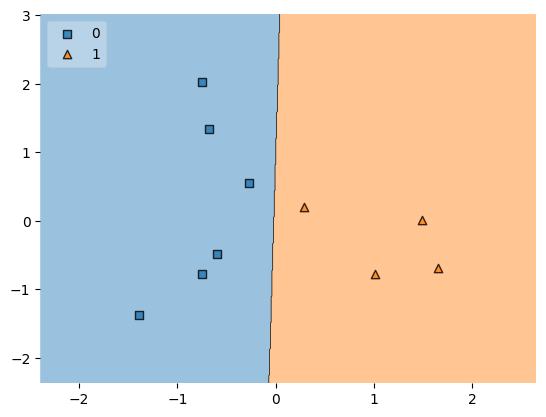

In [48]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test, y_test.values, clf=clf, legend=2)

<Axes: >

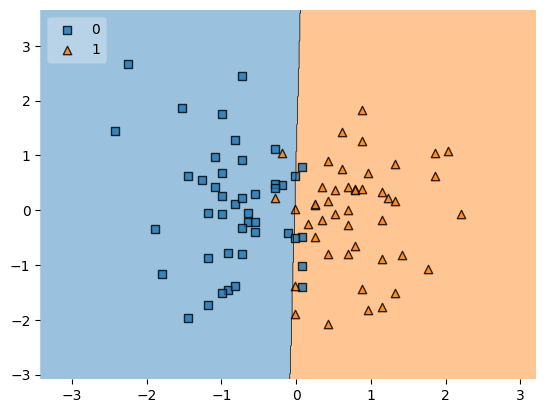

In [45]:
#bigger picture

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [50]:
import pickle

In [51]:
# pickle convers objects into file and this file can be used in other environments
pickle.dump(clf,open("model.pkl","wb"))